In [34]:
#imports fastai's computer-vision toolkit (models, DataBlock, learner, image utils) and Python's standard `Path` for handling paths. 
from fastai.vision.all import *
from pathlib import Path

In [35]:
#Points path at our dataset folder. (PetImages is downloaded separately from kaggle)
path = Path("PetImages")

In [36]:
#List what's inside the PetImages folder (So we did have the images of the cat and the dog)
path.ls()

(#2) [Path('PetImages/Cat'),Path('PetImages/Dog')]

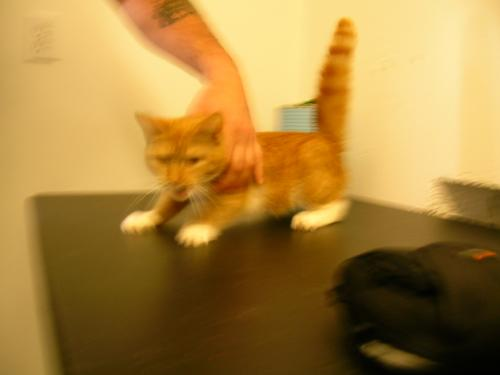

In [37]:
#Grabs every image file path inside the cat folder  into a list and opens the first one as an image object and displays it full-size. 
cat_files = get_image_files(path/"Cat")

img = PILImage.create(cat_files[0])

img

In [38]:
#Scans every image in PetImages and returns a list of paths that are corrupted/unreadable. (remove unusual data)
failed=verify_images(get_image_files(path))
failed
#failed.map(Path.unlink) => Deletes those images from the disk. but since we've done once we'll not do it again. 

(#0) []

In [39]:
"""
pets = DataBlock(...) => Creates a datablock object and stores it in the variable pet. It doesn't load the data immediately. 
pets only include instructions like images are stored here, labels are obtained like this and things. 
"""
# ImageBlock => Tells fastai that input is an image. 
# CategoryBlock => Tells fastai that output is a category (class label)
"""
Image  ------------->  Category
(cat.jpg)                Cat

(dog.jpg)                Dog
"""
# get_items store all the images of the dogs and the cats. 
# valid_pct=0.2 takes 20% of the total dataset as validation set and 80% as training set. seed=42 fixes the randomness.
# get_y=parent_label tells that the folder name is the category or the class label for the images that it had. 
# since neural network requires the same width and same size we need to resize every image. 
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),

    get_items=get_image_files,

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

    get_y=parent_label,

    item_tfms=Resize(224)
)

In [40]:
# It says that execute all the datablock instructions and create dataloaders. This is where fastai gets images and labels and splits the dataset. 
# Neural network train on a group of images. Fewer groups makes training faster
dls = pets.dataloaders(path, bs=32)

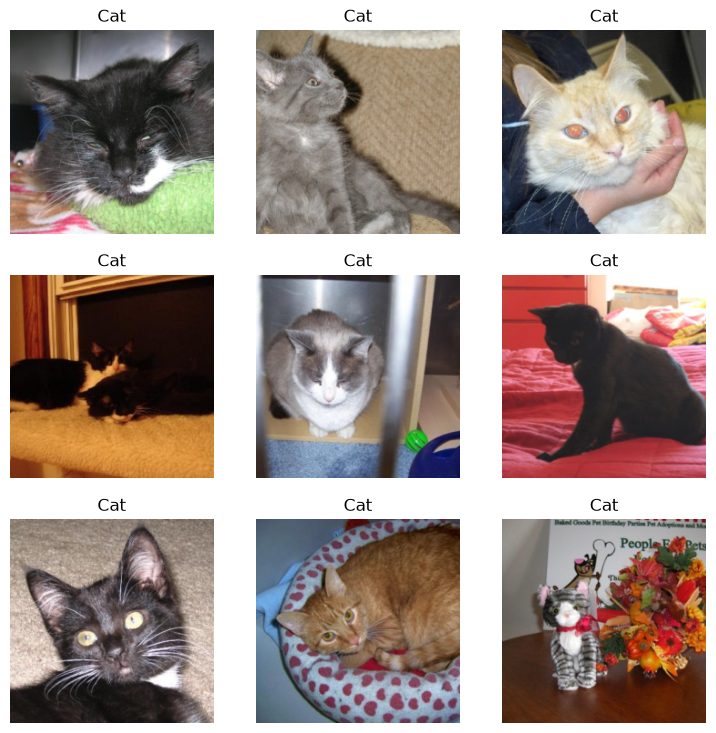

In [41]:
# shows one batch of images along with their labels, so you can verify that the data has been loaded and labeled correctly. 
dls.show_batch(max_n=9)

In [42]:
# Till now datablock describe how to prepare the data. 
# DataLoaders loaded the data into batches. 
# Now vision_learner() creates a learner which combines the data, the neural network, the loss function and the optimizer. 
# learn is a learner object taht knows what data to use, which neural network to use, how to calculate errors and how to improve itself and predicts.
# vision_learner is a fastai function that creates a neural network for computer vision tasks. 
# dls is the dataloaders we created that contain training images and validation images
# resnet-18 is a residual network architecture with 18 learnable layers. It is already trained over million of images across 1000 different class. 
# error_rate is (wrong predictions/total predictions)
learn = vision_learner(
    dls,
    resnet18,
    metrics=error_rate
)

In [43]:
# This tells the learner to train the pretrained ResNet model 1 time on the dataset.
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.711990,0.082174,0.037975,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.155365,0.032063,0.025316,00:23


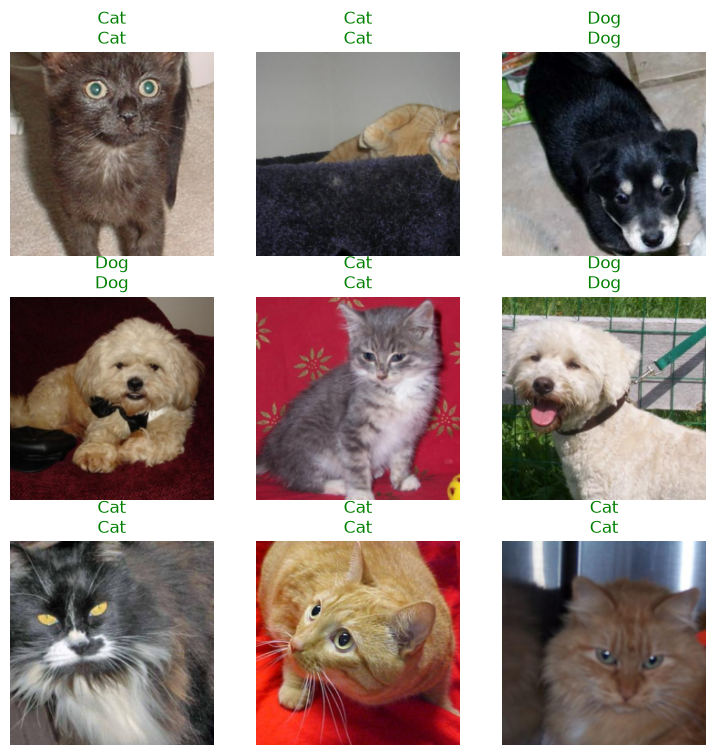

In [30]:
# It shows the input image, actual label and model's predicted label. This help quickly see whether the model is making sensible predictions. 
learn.show_results()

In [44]:
# Predicts a specific image
learn.predict(r"C:\Users\abhis\Downloads\animal.jpg")

('Cat', tensor(0), tensor([9.9998e-01, 1.7238e-05]))

In [45]:
learn.predict(r"C:\Users\abhis\Desktop\Practical Deep Learning\PetImages\Dog\6.jpg")

('Dog', tensor(1), tensor([1.1871e-05, 9.9999e-01]))